Course Project - Rufus Mattsson

The aim of this project is to find out if there is a relationship between playing video games and having higher grades in school.
The dataset used in this study includes 14 different variables (including grade). More specifically, research will be done to find out if the variable gaming_hours impact grades. Additionally, the difference between genders is taken into consideration, and what genre of game is played.

To interact with this project, click "run all cells" in the top left corner. Every part of the study, except the Gemini analysis will work simply by running the cells. Gemini's answer to the prompt can be read in a markdown cell. If you want to test analysing the correlation heatmap with Gemini yourself, you should create a .env file called "Gemini_API" in which you include your personal Gemini API key. 

AI tools, such as Gemini and ChatGPT have been used troughout the project for troubleshooting code.  


In [2]:
#Below the data "Gaming_Academic_Performance.csv" is loaded in directly from my github repository using a permalink
#The dataset can be found in Repository_RufusMattsson/project/dataset

import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/rufusmattsson/Repository_RufusMattsson/e2fc383e345edc315f19e1996fcf0c347440fb17/project/dataset/Gaming_Academic_Performance.csv")
df.head()


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [3]:
df.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

In [4]:
#There appears not to be any missing values in this data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [6]:
df.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


In [7]:
#It seems like there are no weird or impossible values

Text(0.5, 1.0, 'Hours studies vs grades, included hours gaming')

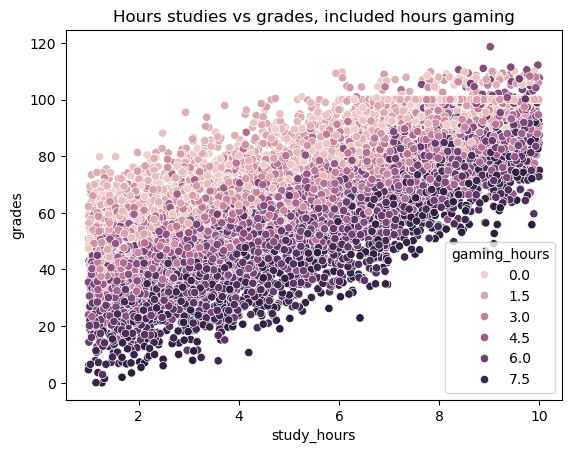

In [8]:
#We can now analyse the data visually:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="study_hours", y="grades", hue="gaming_hours")
plt.title("Hours studies vs grades, included hours gaming")

In [9]:
#From this scatterplot we can see a clear trend. The more hours per day is studied, the higher the grade will be.
#We can also see, however, that people who play less video games tend to have higher grades.

Text(0.5, 1.0, 'Grades vs gaming hours for the different genders')

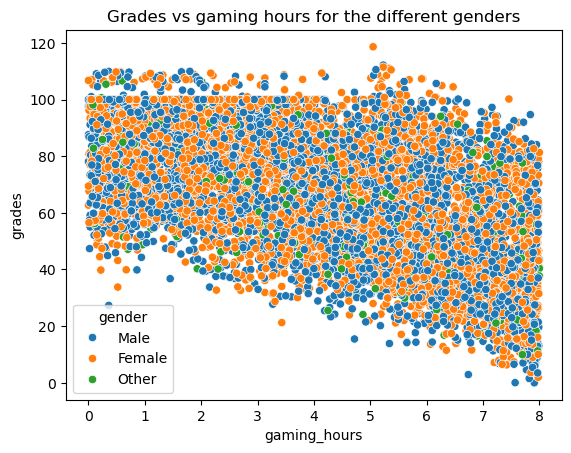

In [10]:
sns.scatterplot(data=df, x="gaming_hours", y="grades", hue="gender")
plt.title("Grades vs gaming hours for the different genders")

Text(0.5, 1.0, 'Hours gamed per day vs grades (per gender)')

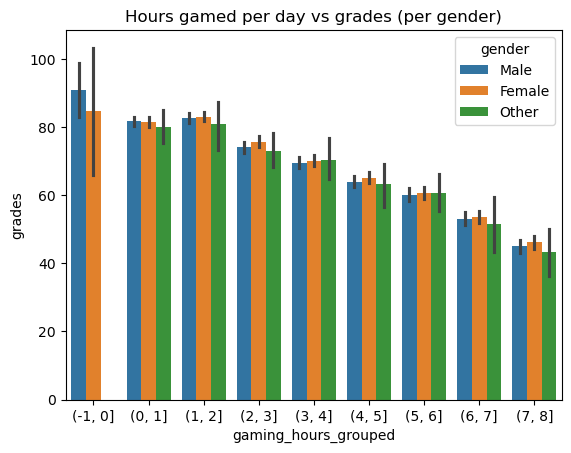

In [11]:
#Cutting gaming_hours into slices to use in the next plot with pd.cut():
df["gaming_hours_grouped"] = pd.cut(df["gaming_hours"], [-1,0,1,2,3,4,5,6,7,8] )
sns.barplot(data=df, x="gaming_hours_grouped", y="grades", hue="gender")
plt.title("Hours gamed per day vs grades (per gender)")

In [12]:
#On the plot above we can see that in general, the people who do not play video games have higher grades.
#However, if you play video games, you will most likely have the highest grades when you spend 1-2 hours per day playing.
#Additionally, non-gaming males seem to have higher grades than non-gaming females.

(df["gaming_hours"]==0).sum()

np.int64(8)

In [13]:
#However, because we only have 8 observations out of 8000 who are in the first category (never plays video games), the plot above 
#should not be regarded as very accurate. 

Text(0.5, 1.0, 'Genre vs grade')

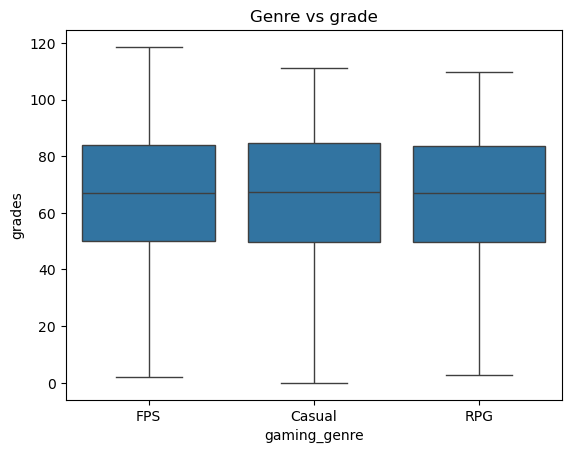

In [14]:
sns.boxplot(data=df, x="gaming_genre", y="grades")
plt.title("Genre vs grade")

Text(0.5, 1.0, 'Genre vs grade, per hours played')

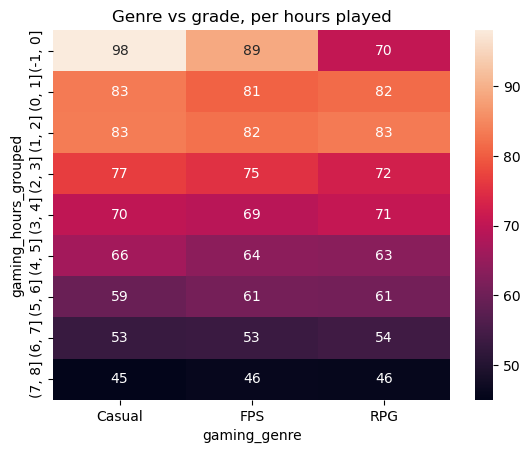

In [15]:
#The above plot shows that median grades are almost identical for gamers in the three genres.
#This hints to the fact that gaming_genre does not play a big role in grades.

pivot = pd.pivot_table(df, 
                       values="grades",
                       index="gaming_hours_grouped",
                       columns="gaming_genre",
                       aggfunc ="mean",
                       observed=False
                      )
sns.heatmap(pivot, annot=True) 
plt.title("Genre vs grade, per hours played")

In [16]:
#The above heatmap shows, again, that the highest means in grades are found in 
#people who don't play video games (keep in mind, there were only 8 of those). 
#If we then ignore the first row, we can see that the difference in mean grades
#is very small across the different genres.


In [17]:
#Next, we make values numeric so that we can inspect the correlation between them and grades.

from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
le_gaming_genre = LabelEncoder()
le_stress_level = LabelEncoder()

df["gender"] = le_gender.fit_transform(df["gender"])
df["gaming_genre"] = le_gaming_genre.fit_transform(df["gaming_genre"])
df["stress_level"] = le_stress_level.fit_transform(df["stress_level"])
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gaming_hours_grouped
0,1,22,1,7.23,8.78,6.96,91.44,1,3.25,9.36,235.84,14.69,1,86.459555,"(7, 8]"
1,2,19,1,0.07,8.72,7.63,63.63,0,1.02,3.21,328.71,2.47,2,98.230000,"(0, 1]"
2,3,23,0,1.73,9.56,4.40,83.26,0,3.46,5.56,313.61,4.73,0,90.560000,"(1, 2]"
3,4,20,0,6.62,1.68,7.83,75.04,2,1.46,11.78,241.84,14.54,1,32.670000,"(6, 7]"
4,5,22,0,5.36,5.83,5.55,65.57,1,1.01,8.23,249.31,12.48,1,58.710000,"(5, 6]"


Text(0.5, 1.0, 'Correlation heatmap for every variable')

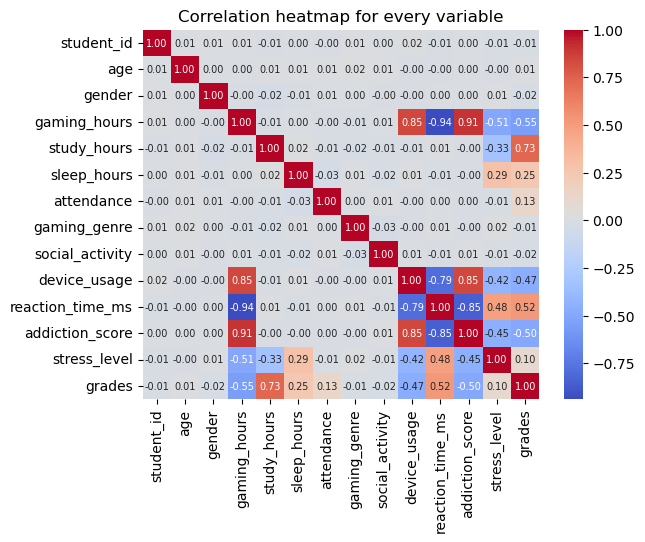

In [18]:
corr=df.corr(numeric_only = True)
sns.heatmap(corr, annot=True, fmt=".2f",cmap="coolwarm",annot_kws={"size": 7})
plt.title("Correlation heatmap for every variable")

In [19]:
#From the heatmap above, we can see that hours gaming per day
#has a negative correlation with grades (-55). Gender, or gaming genre do not 
#appear to correlate with grades. 
#Interesting enough (even though it is not in the scope of this project), 
#gaming hours and reaction time have a strong negative correlation. 
#Gaming and stress levels also seem to have a negative correlation!

In [32]:
!pip install google-genai python-dotenv
from dotenv import load_dotenv
import os
from google import genai

load_dotenv("gemini_api.env")
api_key = os.environ.get("gemini_api_key")
gemini_client = genai.Client(api_key=api_key)
GEMINI_MODEL = "gemini-2.5-flash-lite"

def ask_llm(prompt):
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=prompt
    )
    return response.text

In [35]:
prompt = f"""
Study: 
The aim of this project is to find out if there is a relationship 
between playing video games and having higher grades in school. 
The dataset used in this study includes 14 different variables (including grade). 
More specifically, research will be done to find out if the variable gaming_hours impact grades. 
Additionally, the difference between genders is taken into consideration, and what genre of game is played. 
study The correlations between the different variables are {corr}.
Briefly interpret the result and the possible implications of this with max 10 sentences. 
"""

print(ask_llm(prompt))

The correlation matrix reveals a surprising negative relationship between `gaming_hours` and `grades` (correlation of -0.55). This suggests that as students spend more hours gaming, their grades tend to decrease. Conversely, `study_hours` shows a strong positive correlation with `grades` (correlation of 0.73), indicating that more study time is associated with better academic performance.

Other notable correlations include a strong negative relationship between `gaming_hours` and `reaction_time_ms` (-0.94) and `addiction_score` (0.91), and `device_usage` (0.85). This implies that higher gaming hours are linked to faster reaction times, higher addiction scores, and more device usage.

Interestingly, `reaction_time_ms`, `addiction_score`, and `device_usage` all exhibit negative correlations with `grades`, ranging from -0.47 to -0.50. This further strengthens the idea that the negative impact of excessive gaming on grades might be mediated by these factors.

The study also considered gen

The AI answered: "The correlation matrix reveals a surprising negative relationship between `gaming_hours` and `grades` (correlation of -0.55). This suggests that as students spend more hours gaming, their grades tend to decrease. Conversely, `study_hours` shows a strong positive correlation with `grades` (correlation of 0.73), indicating that more study time is associated with better academic performance.

Other notable correlations include a strong negative relationship between `gaming_hours` and `reaction_time_ms` (-0.94) and `addiction_score` (0.91), and `device_usage` (0.85). This implies that higher gaming hours are linked to faster reaction times, higher addiction scores, and more device usage.

Interestingly, `reaction_time_ms`, `addiction_score`, and `device_usage` all exhibit negative correlations with `grades`, ranging from -0.47 to -0.50. This further strengthens the idea that the negative impact of excessive gaming on grades might be mediated by these factors.

The study also considered gender and gaming genre, but their correlations with `grades` are very close to zero, suggesting they might not be significant direct predictors of academic performance in this dataset.

In summary, the findings indicate a potential negative impact of extensive video game playing on academic grades, possibly linked to increased device usage, addiction, and altered reaction times. These results highlight the importance of balancing gaming with study and other activities for students' academic success."

Conclusions from the project: 

More hours of gaming per day appears to have a negative impact on school grades. The same is true for all video game genres and genders. However, according to the barplot "Hours gamed per day vs grades (per gender)", gaming for 1-2 hours per day could impact grades more positively than only playing for under an hour. Because the data only contained 8 instances of 0.00 hours of gaming, the grades of non-gamers should be taken with a grain of salt. 

In [38]:
df.to_csv("cleaned_data.csv")